# Process
### EXPLORATORY DATA ANALYSIS
### FEATURE ENGINEERING
### DATA PREPROCESSING
### DATA LOADING
### MODEL BUILDING
### MODEL TRAINING
### MODULARIZATION
### EXPERIMENT TRACKING
### MODEL EVALUATION
### INFERENCE PIPELINE
### API DEPLOYMENT
### DOCKERIZATION AND DCLOUD DEPLYOMENT 


In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### EXPLORATORY DATA ANALYSIS
1. data collection
2. seperate data into features and targets
3. handle missing values and completeness
4. ensure correct data dtypes for analysis and modeling
5. handle univariate analysis of target data
6. handle univariate analysis of predictor data
7. check whither missing data correlates with the target
8. handle bivariate analysis for numerical and categorical data
9. establish a correlation structure & multicollinearity
10. check for outlifers and leverage points


In [10]:
# data collection
data_frame = pd.read_csv('data/heart_disease.csv')
print(data_frame.shape)
display(data_frame.head())
display(data_frame.sample(5))
print(data_frame.dtypes)


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
219,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0
11,43,0,0,132,341,1,0,136,1,3.0,1,0,3,0
975,39,1,0,118,219,0,1,140,0,1.2,1,0,3,0
402,70,1,1,156,245,0,0,143,0,0.0,2,0,2,1
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## Label Meanings
- age = age: 29-77
- sex = what is the sex of the person: 1 = male, 0 = female
- trestbps = resting blood pressure: 94-200mm Hg
- cp = chest pain type (4 values): 0,1,2,3
- chol = serum cholestoral in mg/dl: 126 - 564 mg/dl
- fbs = fasting blood sugar > 120 mg/dl: 1 = true, 0 = false
- restecg = resting electrocardiographic results (values 0,1,2): 0-2
- thalach = maximum heart rate achieved: 71 - 202
- exang = exercise induced angina: 1 = yes, 0 = no
- oldpeak = ST depression induced by exercise relative to rest: 0-6.2
- slope = the slope of the peak exercise ST segment: 0-2
- ca = number of major vessels (0-3) colored by flourosopy: 0-3
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- The names and social security numbers of the patients were recently - removed from the database, replaced with dummy values.

In [11]:
# extract target from features
target_values = data_frame['target']
target = 'target'
features = [c for c in data_frame.columns if c != target]
feature_values = data_frame[features]
display(target_values.sample(10))
display(feature_values.sample(10))

125    1
429    0
888    0
220    0
849    0
952    1
412    0
958    1
690    1
18     1
Name: target, dtype: int64

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
135,58,0,0,170,225,1,0,146,1,2.8,1,2,1
763,58,0,3,150,283,1,0,162,0,1.0,2,0,2
393,62,0,0,160,164,0,0,145,0,6.2,0,3,3
60,29,1,1,130,204,0,0,202,0,0.0,2,0,2
745,51,1,2,100,222,0,1,143,1,1.2,1,0,2
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
227,44,0,2,118,242,0,1,149,0,0.3,1,1,2
976,63,0,0,108,269,0,1,169,1,1.8,1,2,2
96,57,0,0,128,303,0,0,159,0,0.0,2,1,2
950,67,1,0,160,286,0,0,108,1,1.5,1,3,2


Text(0.5, 1.0, 'Missingness Map')

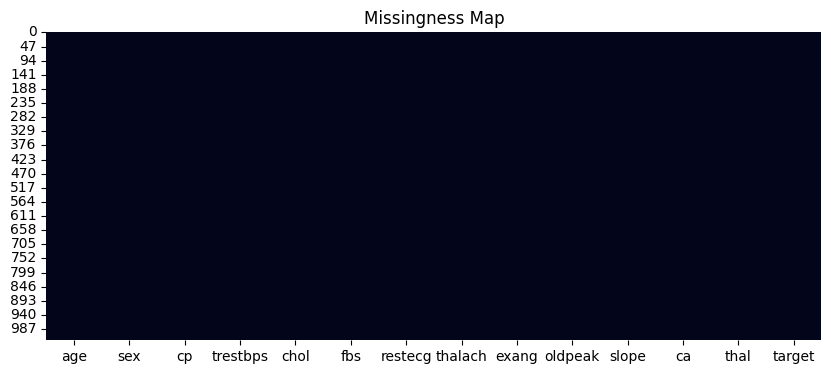

In [12]:
# handling missing values and completedness

# compute missing values AND their percentages
missing_data = data_frame.isna().sum().sort_values(ascending=False)
missing_percentage = (missing_data/len(data_frame))*100
pd.concat([missing_data, missing_percentage], axis=1, keys=['count','percentage']).head(20)
# visualize the missingness matrix through a heatmap
plt.figure(figsize=(10,4))
sns.heatmap(data_frame.isna(), cbar=False)
plt.title("Missingness Map")

In [13]:
# ensure correct data dtypes for analysis and modeling
categ_columns = data_frame.select_dtypes(include=['object']).columns
for c in categ_columns:
    print(c)

'''
    some of the categorical data is in int64 form. so we will instead, 
    look for the features that have few unique values.

    We will treat columns with few unique values or string data as categorical
'''
categ_columns = [col for col in data_frame.columns 
                 if data_frame[col].dtype == 'object' or
                 (data_frame[col].nunique() < 5 and data_frame[col].dtype in ['int64', 'float64'])]
print(categ_columns)
# convert the category features to type 'category'
for c in categ_columns:
    data_frame[c] = data_frame[c].astype('category')

# verify this type change
data_frame.info()

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1025 non-null   int64   
 1   sex       1025 non-null   category
 2   cp        1025 non-null   category
 3   trestbps  1025 non-null   int64   
 4   chol      1025 non-null   int64   
 5   fbs       1025 non-null   category
 6   restecg   1025 non-null   category
 7   thalach   1025 non-null   int64   
 8   exang     1025 non-null   category
 9   oldpeak   1025 non-null   float64 
 10  slope     1025 non-null   category
 11  ca        1025 non-null   int64   
 12  thal      1025 non-null   category
 13  target    1025 non-null   category
dtypes: category(8), float64(1), int64(5)
memory usage: 57.3 KB


605    1
998    0
899    1
279    1
500    1
810    0
225    1
309    1
331    0
78     1
Name: target, dtype: category
Categories (2, int64): [0, 1]

Text(0.5, 1.0, 'Target Distribution')

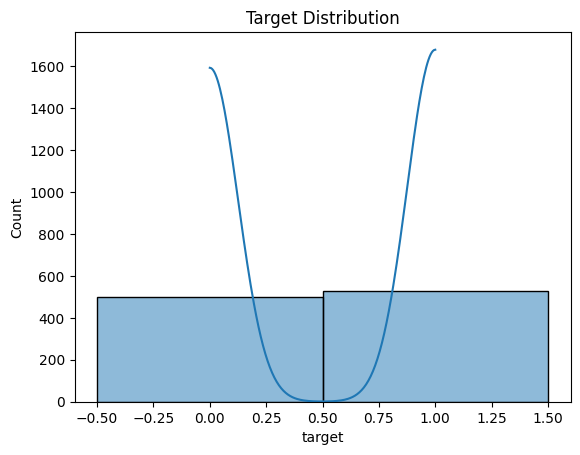

In [14]:
# univariate analysis - target first
'''
    we now must understand target distributions
'''
display(data_frame[target].sample(10))
data_frame[target].describe()
sns.histplot(data_frame[target], kde=True)
plt.title('Target Distribution')


<Axes: title={'center': 'Target Distribution including Boxplot'}, xlabel='target', ylabel='Count'>

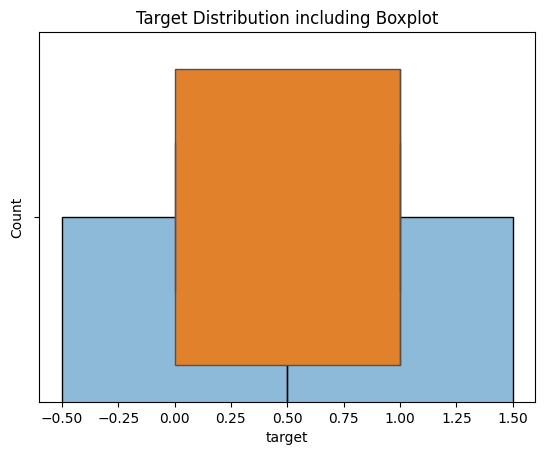

In [15]:
data_frame[target].describe()
sns.histplot(data_frame[target], kde=True)
plt.title('Target Distribution including Boxplot')
sns.boxplot(x=data_frame[target])

age count    1025.000000
mean       54.434146
std         9.072290
min        29.000000
25%        48.000000
50%        56.000000
75%        61.000000
max        77.000000
Name: age, dtype: float64
trestbps count    1025.000000
mean      131.611707
std        17.516718
min        94.000000
25%       120.000000
50%       130.000000
75%       140.000000
max       200.000000
Name: trestbps, dtype: float64
chol count    1025.00000
mean      246.00000
std        51.59251
min       126.00000
25%       211.00000
50%       240.00000
75%       275.00000
max       564.00000
Name: chol, dtype: float64
thalach count    1025.000000
mean      149.114146
std        23.005724
min        71.000000
25%       132.000000
50%       152.000000
75%       166.000000
max       202.000000
Name: thalach, dtype: float64
oldpeak count    1025.000000
mean        1.071512
std         1.175053
min         0.000000
25%         0.000000
50%         0.800000
75%         1.800000
max         6.200000
Name: oldpeak, dtype

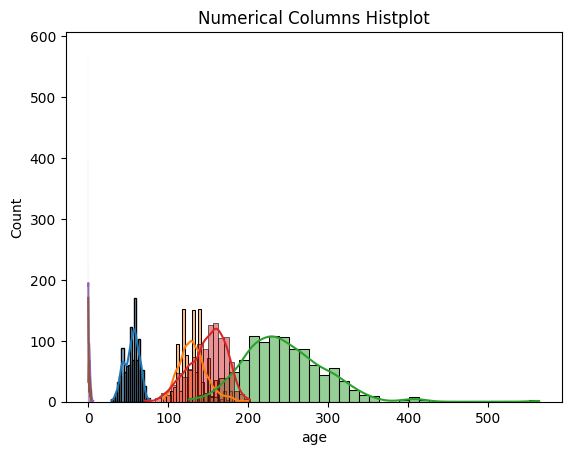

In [17]:
# univariate analysis - ALL PREDICTORS
'''
    all the predictors are the features of the dataframe
'''

# make distribution for numerical features
numerical_colums = data_frame.select_dtypes(include=['int64', 'float64']).columns.tolist()
for c in numerical_colums:
    print(c, data_frame[c].describe())
    sns.histplot(data_frame[c].dropna(), kde=True)
    plt.title("Numerical Columns Histplot")
    plt.show

age count    1025.000
mean       54.434
std         9.072
min        29.000
25%        48.000
50%        56.000
75%        61.000
max        77.000
Name: age, dtype: float64
sex count    1025.000
mean        0.696
std         0.460
min         0.000
25%         0.000
50%         1.000
75%         1.000
max         1.000
Name: sex, dtype: float64
cp count    1025.000
mean        0.942
std         1.030
min         0.000
25%         0.000
50%         1.000
75%         2.000
max         3.000
Name: cp, dtype: float64
trestbps count    1025.000
mean      131.612
std        17.517
min        94.000
25%       120.000
50%       130.000
75%       140.000
max       200.000
Name: trestbps, dtype: float64
chol count    1025.000
mean      246.000
std        51.593
min       126.000
25%       211.000
50%       240.000
75%       275.000
max       564.000
Name: chol, dtype: float64
fbs count    1025.000
mean        0.149
std         0.357
min         0.000
25%         0.000
50%         0.000
75%     

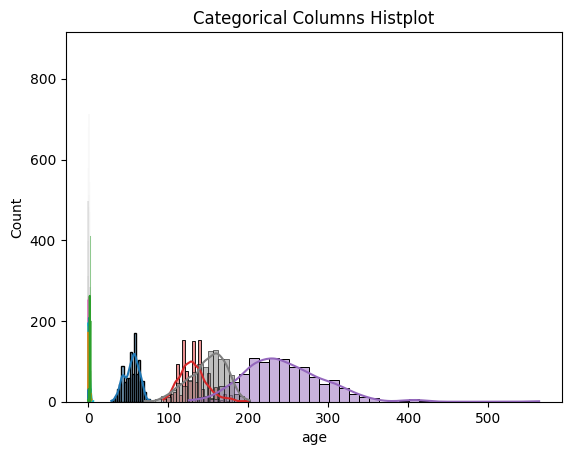

In [ ]:
# get only categorical features

# data_frame[col].dtype == 'object'
cat_features = [c for c in data_frame.columns if c != "target"]
for c in data_frame[cat_features]:
    print(c, data_frame[c].describe().round(3))
    sns.histplot(data_frame[c].dropna(), kde=True)
    plt.title("Categorical Columns Histplot")
    plt.show